## 1. Importación de Librerías Necesarias

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Carga de Datos - Dataset Train

In [14]:
df_train = pd.read_csv('../clean_data/dataset_train.csv', sep='|')

print(f"  - Shape: {df_train.shape}")
print(f"\nColumnas disponibles:")
print(df_train.columns.tolist())
print(f"\nPrimeras 5 filas:")
print(df_train.head())
print(f"\nTipos de datos:")
print(df_train.dtypes)

  - Shape: (343, 14)

Columnas disponibles:
['id_venta', 'id_producto', 'cantidad', 'total', 'fecha_venta', 'id_cliente', 'nombre_cliente', 'medio_pago', 'producto', 'categoria', 'precio', 'email', 'ciudad', 'fecha_alta_cli']

Primeras 5 filas:
   id_venta  id_producto  cantidad  total fecha_venta  id_cliente  \
0         1           90         1   2902  2024-06-19          62   
1         2           82         5  11970  2024-03-17          49   
2         2           39         5   2345  2024-03-17          49   
3         2           70         2   8122  2024-03-17          49   
4         2           22         1   2069  2024-03-17          49   

     nombre_cliente  medio_pago               producto  categoria  precio  \
0  GUADALUPE ROMERO           1    TOALLAS HÚMEDAS X50          0    2902   
1      OLIVIA GOMEZ           2  ACEITUNAS NEGRAS 200G          1    2394   
2      OLIVIA GOMEZ           2     HELADO VAINILLA 1L          1     469   
3      OLIVIA GOMEZ           2 

## 3. Ingeniería de Features - Creación del Target (y)

In [15]:
frecuencia_clientes = df_train['id_cliente'].value_counts().reset_index() # Calcular la frecuencia de compra de cada cliente

frecuencia_clientes.columns = ['id_cliente', 'frecuencia_compra']


umbral_mediana = frecuencia_clientes['frecuencia_compra'].median() # Calcular la mediana de frecuencias

print(f"Estadísticas de Frecuencia de Compra:")
print(f"  - Media: {frecuencia_clientes['frecuencia_compra'].mean():.2f}")
print(f"  - Mediana (umbral): {umbral_mediana:.2f}")
print(f"  - Mínimo: {frecuencia_clientes['frecuencia_compra'].min()}")
print(f"  - Máximo: {frecuencia_clientes['frecuencia_compra'].max()}")
print(f"\n✓ Umbral de frecuencia establecido en: {umbral_mediana}")

Estadísticas de Frecuencia de Compra:
  - Media: 5.12
  - Mediana (umbral): 4.00
  - Mínimo: 1
  - Máximo: 15

✓ Umbral de frecuencia establecido en: 4.0


In [16]:
df_train = df_train.merge(frecuencia_clientes, on='id_cliente', how='left')
df_train['es_cliente_frecuente'] = (df_train['frecuencia_compra'] >= umbral_mediana).astype(int) # Crear col 'es_cliente_frecuente'


print(f"\nDistribución de la variable target:")
print(df_train['es_cliente_frecuente'].value_counts())
print(f"\nProporción:")
print(df_train['es_cliente_frecuente'].value_counts(normalize=True))


Distribución de la variable target:
es_cliente_frecuente
1    290
0     53
Name: count, dtype: int64

Proporción:
es_cliente_frecuente
1    0.845481
0    0.154519
Name: proportion, dtype: float64


## 4. Preparación de Datos para el Modelo

In [17]:
features = ['medio_pago', 'precio', 'categoria','ciudad','cantidad']
X = df_train[features].copy()
y = df_train['es_cliente_frecuente'].copy()

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")


print(f"\nPrimeras 5 filas de X:")
print(X.head())
print(f"\nEstadísticas de X:")
print(X.describe())

Shape de X: (343, 5)
Shape de y: (343,)

Primeras 5 filas de X:
   medio_pago  precio  categoria  ciudad  cantidad
0           1    2902          0       0         1
1           2    2394          1       1         5
2           2     469          1       1         5
3           2    4061          1       1         2
4           2    2069          1       1         1

Estadísticas de X:
       medio_pago       precio   categoria      ciudad    cantidad
count  343.000000   343.000000  343.000000  343.000000  343.000000
mean     1.361516  2654.495627    0.833819    2.413994    2.962099
std      1.140909  1308.694720    0.372787    1.705866    1.366375
min      0.000000   272.000000    0.000000    0.000000    1.000000
25%      0.000000  1618.500000    1.000000    1.000000    2.000000
50%      1.000000  2512.000000    1.000000    2.000000    3.000000
75%      2.000000  3876.000000    1.000000    4.000000    4.000000
max      3.000000  4982.000000    1.000000    5.000000    5.000000


In [18]:
X_train, X_test, y_train, y_test = train_test_split(   # Dividir los datos en entrenamiento y prueba

    X, y, test_size=0.2, random_state=42
)

print(f"\nTamaños:")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_test: {X_test.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test: {y_test.shape}")
print(f"\nDistribución en train:")
print(y_train.value_counts())
print(f"\nDistribución en test:")
print(y_test.value_counts())


Tamaños:
  - X_train: (274, 5)
  - X_test: (69, 5)
  - y_train: (274,)
  - y_test: (69,)

Distribución en train:
es_cliente_frecuente
1    232
0     42
Name: count, dtype: int64

Distribución en test:
es_cliente_frecuente
1    58
0    11
Name: count, dtype: int64


## 5. Modelado, Entrenamiento y Evaluación

In [19]:
modelo = DecisionTreeClassifier(random_state=42) 

modelo.fit(X_train, y_train)

print(f"  - max_depth: None")
print(f"  - random_state: 42")
print(f"  - Número de features: {modelo.n_features_in_}")
print(f"  - Feature names: {features}")

  - max_depth: None
  - random_state: 42
  - Número de features: 5
  - Feature names: ['medio_pago', 'precio', 'categoria', 'ciudad', 'cantidad']


In [20]:
modelo.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
y_pred = modelo.predict(X_test)

print(f"\nPrimeras 10 predicciones:")
print(y_pred[:10])


Primeras 10 predicciones:
[1 1 1 1 1 1 1 1 1 1]


Calcular accuracy

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'='*50}")
print(f"MÉTRICAS DE EVALUACIÓN")
print(f"{'='*50}")
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


MÉTRICAS DE EVALUACIÓN

Accuracy: 0.7971 (79.71%)


In [23]:
print(f"\nClassification Report:")
print(f"{'-'*50}")
report = classification_report(y_test, y_pred, target_names=['No Frecuente', 'Frecuente'])
print(report)


Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

No Frecuente       0.20      0.09      0.12        11
   Frecuente       0.84      0.93      0.89        58

    accuracy                           0.80        69
   macro avg       0.52      0.51      0.51        69
weighted avg       0.74      0.80      0.76        69



## 6. Visualización - Árbol de Decisión

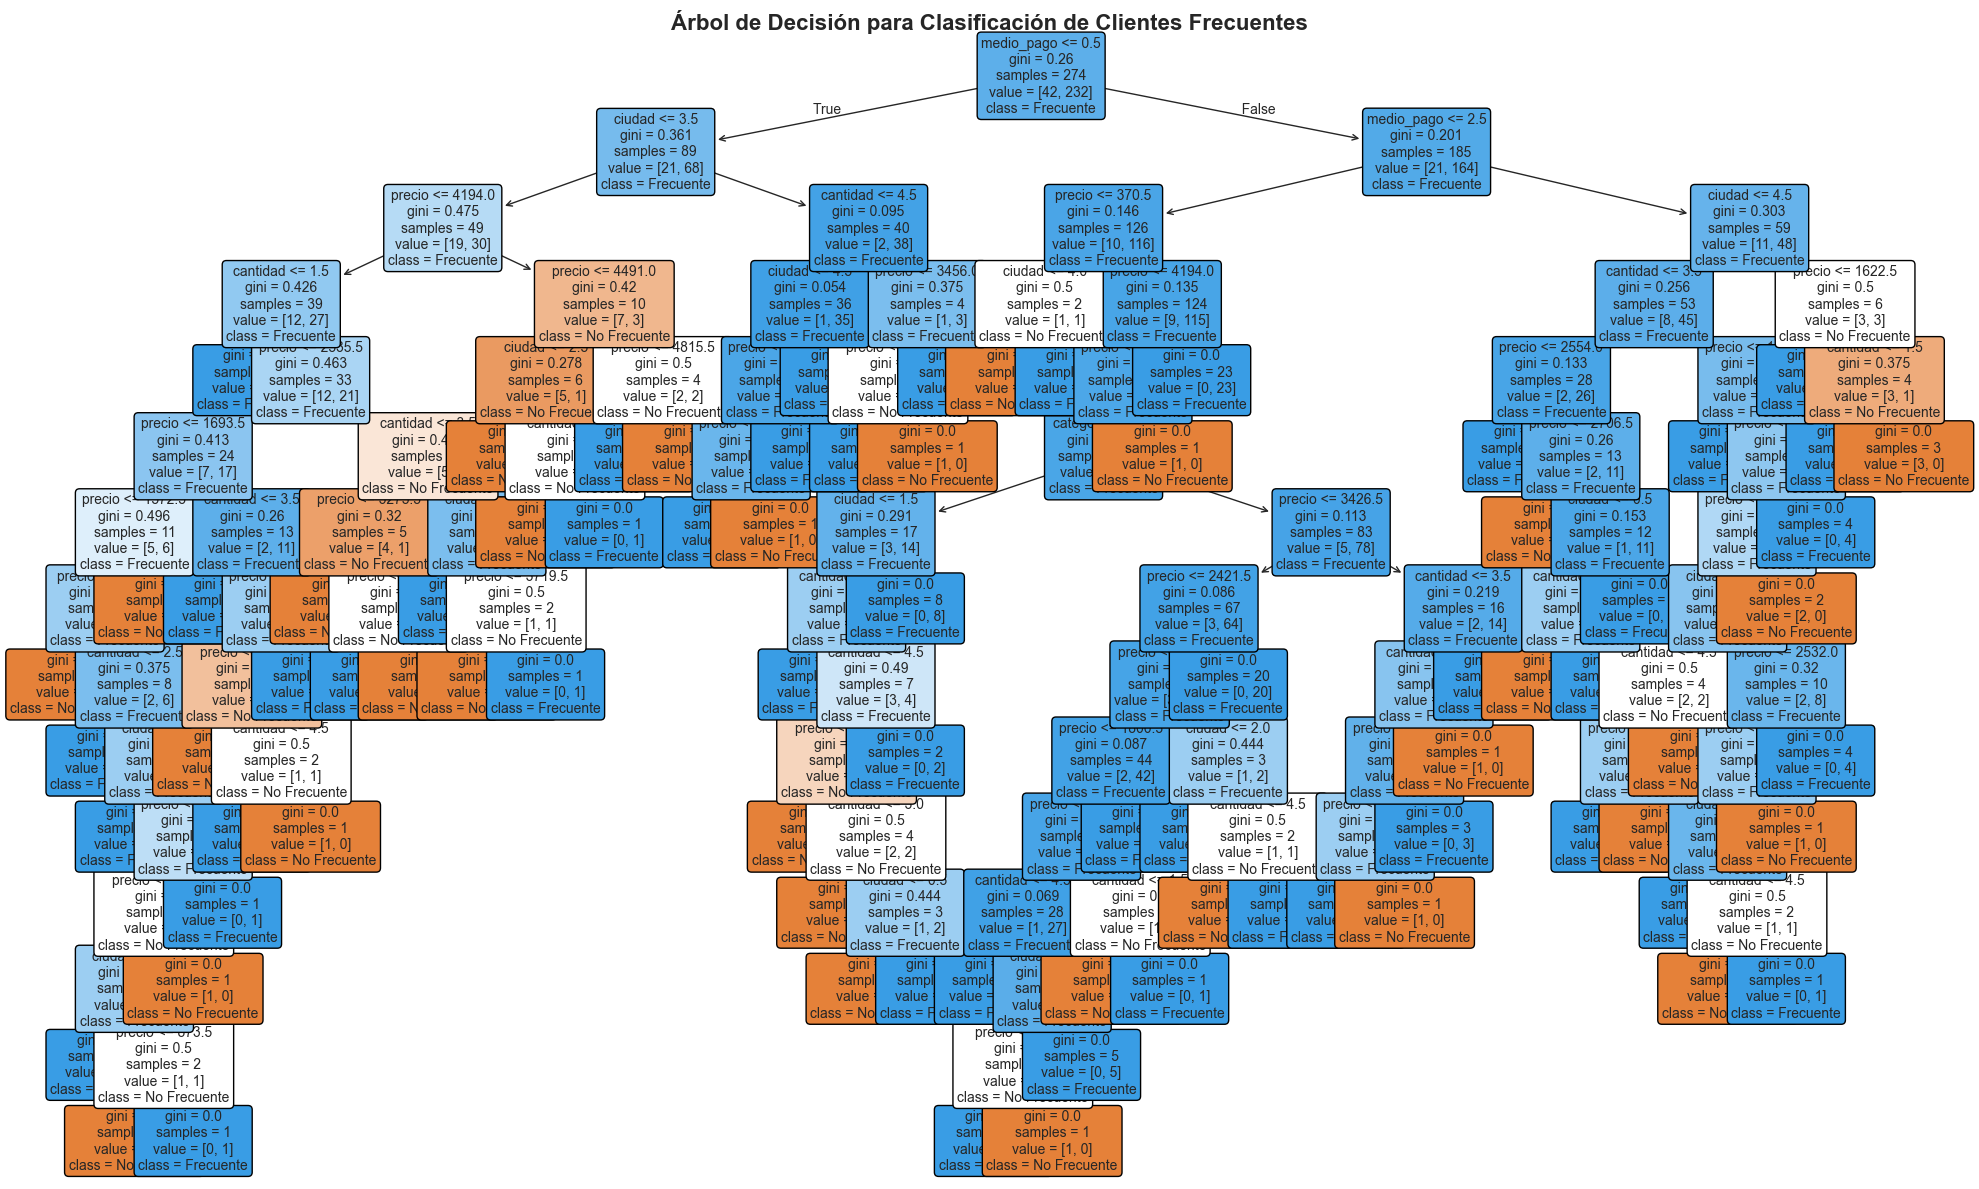

In [24]:
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(
    modelo,
    feature_names=['medio_pago', 'precio', 'categoria','ciudad','cantidad'],
    class_names=['No Frecuente', 'Frecuente'],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=10
)
plt.title('Árbol de Decisión para Clasificación de Clientes Frecuentes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Visualización - Matriz de Confusión

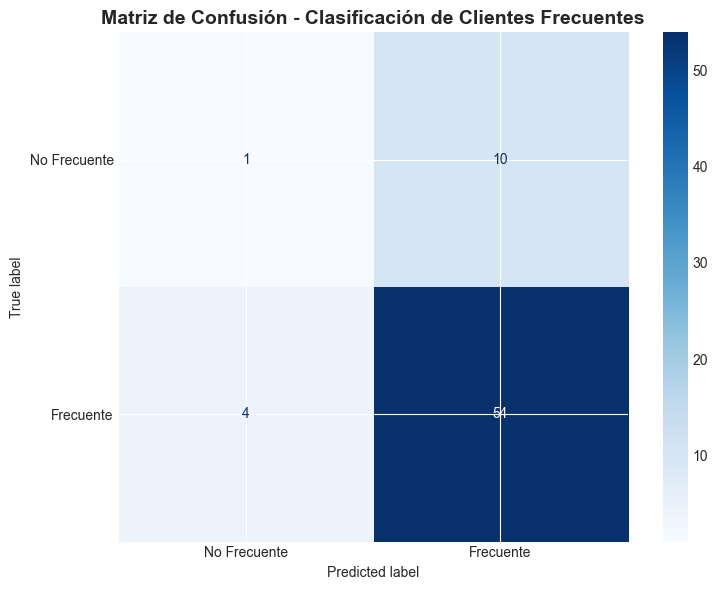

In [25]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Frecuente', 'Frecuente'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Clasificación de Clientes Frecuentes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## 8. Análisis de Resultados

In [26]:
# Detalles matriz de confusión
tn, fp, fn, tp = cm.ravel()

print(f"\n{'='*50}")
print(f"ANÁLISIS DE MATRIZ DE CONFUSIÓN")
print(f"{'='*50}")
print(f"\nVerdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Cálculo de métricas adicionales
sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0
especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"\nSensibilidad : {sensibilidad:.4f}")
print(f"Especificidad: {especificidad:.4f}")
print(f"Precisión: {precision:.4f}")


ANÁLISIS DE MATRIZ DE CONFUSIÓN

Verdaderos Negativos (TN): 1
Falsos Positivos (FP): 10
Falsos Negativos (FN): 4
Verdaderos Positivos (TP): 54

Sensibilidad : 0.9310
Especificidad: 0.0909
Precisión: 0.8438


## 9. Importancia de Features

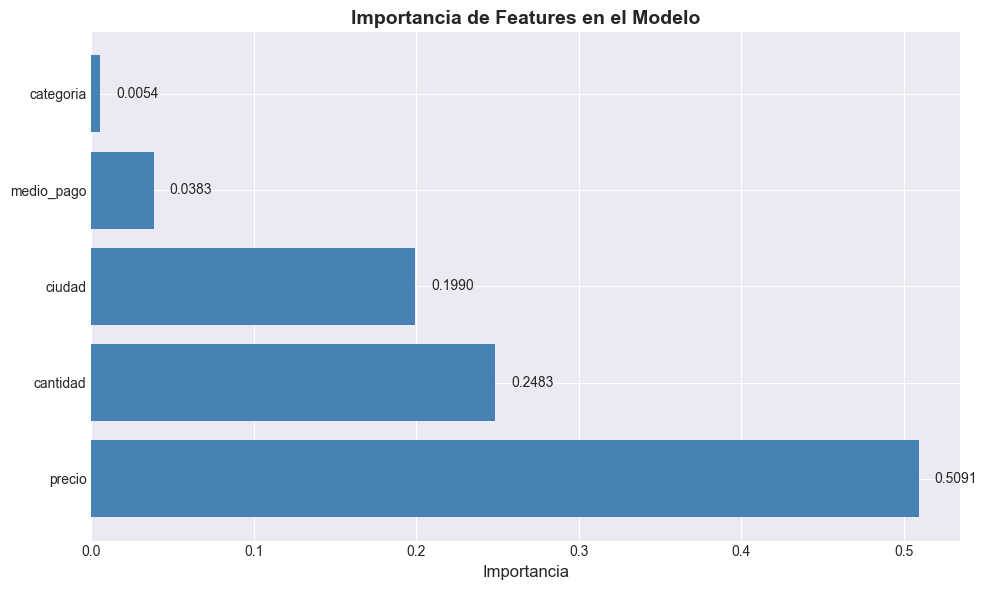

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
importances = modelo.feature_importances_
indices = np.argsort(importances)[::-1]

bars = ax.barh(range(len(importances)), importances[indices], color='steelblue')
ax.set_yticks(range(len(importances)))
ax.set_yticklabels([features[i] for i in indices])
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Importancia de Features en el Modelo', fontsize=14, fontweight='bold')

for i, v in enumerate(importances[indices]):  # Agrega valores en las barras
    ax.text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

